<a href="https://colab.research.google.com/github/FernandaChacara/PML/blob/main/Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 15.1434
Epoch 2/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.6735
Epoch 3/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.0661
Epoch 4/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.7461
Epoch 5/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.4887
Epoch 6/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.2748
Epoch 7/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.0897  
Epoch 8/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9316  
Epoch 9/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8134
Epoch 10/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7172
Epoch 11/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6483
Epoch 12/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5978
Epoch 13/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5684
Epoch 14/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5445
Epoch 15/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.

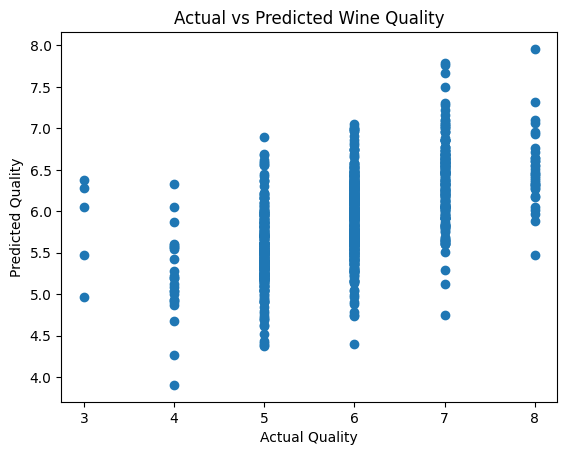

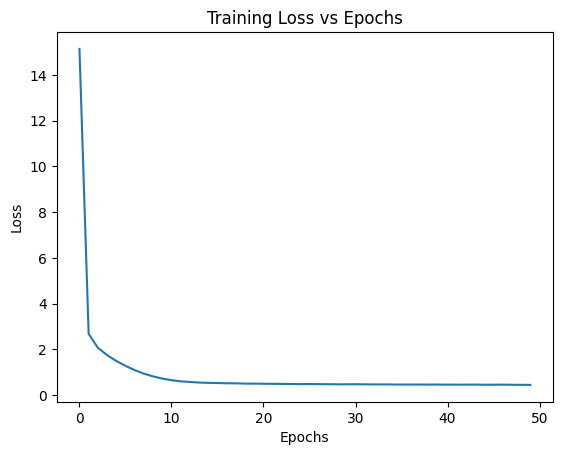

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
data = pd.read_csv(url, sep=';')

# INPUT (explanatory variables)
X = data.drop("quality", axis=1)

# OUTPUT (response variable)
y = data["quality"]

# Split into train dataset and test dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# MODEL
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

# LOSS FUNCTION
model.compile(
    optimizer='adam',
    loss='mse'
)

# TRAINING
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32
)

# PREDICT
predictions = model.predict(X_test)

# Plot 1: Actual vs Predicted
plt.scatter(y_test, predictions)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Actual vs Predicted Wine Quality")
plt.show()

# Plot 2: Loss vs Epochs
plt.plot(history.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.show()